Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно
***

# Введение: почему pandas? (1 pt)

Представьте: вам нужно проанализировать данные о пассажирах «Титаника» — 891 человек, 14 характеристик на каждого (пол, возраст, класс каюты, выживаемость и др.). 

В **табличном редакторе** (Excel):
- Ручной подсчёт среднего возраста выживших займёт минуты  
- Фильтрация «женщины первого класса» требует нескольких кликов  
- Анализ взаимосвязи «тариф - выживаемость» почти невозможен без макросов  

С помощью **Pandas**:
```python
df[df['survived'] == 1]['age'].mean()  # Средний возраст выживших — одна строка кода
```

А теперь представьте, если бы данных было больше!

Библиотека `pandas` нужна для работы именно с табличными данными. Однако табличные данные в жизни — это не единая сущность, а много разных форматов.   

**Форматы табличных файлов**

В реальной работе данные хранятся в разных форматах. Pandas умеет читать основные из них:

| Формат | Метод Pandas | Когда используется |
|--------|--------------|-------------------|
| **CSV** (Comma-Separated Values) | `pd.read_csv()` | Стандарт для обмена табличными данными (простой текст, легко читается) |
| **Excel** (.xlsx, .xls) | `pd.read_excel()` | Бизнес-отчёты, собранные данные |
| **JSON** | `pd.read_json()` | Данные от веб-API, вложенные структуры |
| **Встроенные датасеты** | `seaborn.load_dataset()` | Быстрый старт без скачивания файлов, но скорее для обучения |

> Подробнее можно почитать в [документации](https://pandas.pydata.org/docs/user_guide/io.html).

Для этого задания мы используем классический датасет **Titanic**, доступный «из коробки» через библиотеку Seaborn.

In [ ]:
# Возможно вам надо установить библиотеки
%pip install ... 

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

Прежде, чем мы перейдем к работе с нашими данными давайте познакомимся с основой `pandas`.

Всё в Pandas строится вокруг двух ключевых типов данных:

| Структура | Описание | Аналогия | Пример |
|-----------|----------|----------|--------|
| **`pd.Series`** | Одномерный массив с **именованными индексами** | Столбец в Excel | `[20, 22, 19]` с индексами `['Анна', 'Борис', 'Вера']` |
| **`pd.DataFrame`** | Двумерная таблица из **нескольких Series** с общим индексом | Вся таблица Excel | Несколько столбцов (имя, возраст, ...) |

**Главное отличие**:  
- `Series` — один столбец данных + индекс  
- `DataFrame` — таблица из нескольких столбцов (`Series`), объединённых общим индексом

> Подробнее в документации: [pandas.Series](https://pandas.pydata.org/docs/reference/api/pandas.Series.html), [pandas.DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).

Многие функции возвращают эти типы данных или принимают их на вход. Конечно, мы будем работать с готовыми таблицами, но иногда важно уметь **создавать свои**.

In [2]:
# Создание Series из списка
grades = pd.Series([85, 92, 78, 95], index=['Анна', 'Борис', 'Вера', 'Глеб'])
print("Series:")
grades

Series:


Анна     85
Борис    92
Вера     78
Глеб     95
dtype: int64

In [3]:
# Создание DataFrame из словаря
data = {
    'имя': ['Анна', 'Борис', 'Вера', 'Глеб'],
    'возраст': [20, 22, 19, 21],
    'оценка': [5, 4, 3, 5]
}
df_example = pd.DataFrame(data, index=['студент_1', 'студент_2', 'студент_3', 'студент_4'])
print("DataFrame:")
df_example

DataFrame:


,имя,возраст,оценка
студент_1,Анна,20,5
студент_2,Борис,22,4
студент_3,Вера,19,3
студент_4,Глеб,21,5


> В примере названия столбцов и строк написаны на русском, но **ТАК ДЕЛАТЬ НЕ НАДО**. Лучше всего давать понятные названия на английском.

### Создание Series (0,5 pt)

In [ ]:
# ЗАДАНИЕ: Создайте Series с названиями дней недели (понедельник–воскресенье) 
#          и количеством пар у вас в этот день в качестве значений.
#          Используйте английские названия дней как индекс (можно сократить).

days_series = pd.Series(..., index=[...])

days_series

Так можно получить отдельно индексы и отдельно значения

In [ ]:
days_series.index

In [ ]:
days_series.values

> В [документации](https://pandas.pydata.org/docs/reference/api/pandas.Series.html) указаны все **атрибуты** (то, что вызывается через точку, но без скобок) и **методы** (то, что вызывается через точку и со скобками)

### Создание DataFrame (0,5 pt)

In [ ]:
# ЗАДАНИЕ: Создайте DataFrame из словаря со следующими данными:
#          - Столбец 'город': ['Москва', 'Санкт-Петербург', 'Новосибирск']
#          - Столбец 'население': [12_500_000, 5_400_000, 1_600_000]
#          - Столбец 'регион': ['Центр', 'Северо-Запад', 'Сибирь']
#          Установите 'город' как индекс таблицы (параметр index=...)

cities_data = {
    ...
    }
cities_df = pd.DataFrame(cities_data, index=[...])

cities_df

> В [документации](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) можно посмотреть и другие методы создания датафреймов.

# Работа с таблицами в Pandas

Теперь перейдем к работе с уже готовой таблицей. Для этого нам нужно загрузить данные.  
В этот раз мы будем использовать _встроенный датасет_, но потом нам придется использовать и другие методы считывания данных.

In [4]:
# Так же, как и pandas принято сокращать до pd,
# так и объекты типа DataFrame часто называют df (или data)

df = sns.load_dataset('titanic')

### Знакомство с данными (2 pt)

Перед анализом всегда нужно «осмотреть» данные. Базовый чек-лист:

| Метод | Что показывает | Пример использования |
|-------|----------------|----------------------|
| `.head(n)` | Первые `n` строк | `df.head(3)` — первые 3 строки |
| `.info()` | Типы данных, количество непустых значений | `df.info()` — найти пропуски и типы |
| `.describe()` | Статистика по числовым столбцам (среднее, мин/макс, квартили) | `df.describe()` — понять распределение |
| `.shape` | Размер датасета (строки, столбцы) | `df.shape[0]` — количество записей |
| `.columns` | Список названий столбцов | `df.columns.tolist()` |

Выведите первые 10 строк датасета и изучите их

In [ ]:
df.head(...)

Кстати, сколько всего записей в таблице? Какого таблица размера?

In [ ]:
...

Изучите статистику таблицы и **напишите краткий вывод** о том, какие данные есть в таблице (каких типов, сколько, насколько данные «разбросаны» и так далее).

In [ ]:
...

In [ ]:
# ЗАДАНИЕ: Поменяйте тип ячейки на Marcdown, удалите комментарий и напишите вывод
**ВЫВОД:**

Также для дальнейшего доступа и анализа нам важно знать, какие столбцы есть в таблице. Давайте отдельно посмотрим на **названия столбцов**.

In [ ]:
column_names = ...
print(column_names)

### Базовое «распределение» данных (1 pt)

Перед фильтрацией и агрегацией данных важно понять **распределение значений** в столбцах. Особенно для категориальных признаков (какие это столбцы?).

| Метод | Назначение | Пример для Titanic |
|-------|------------|-------------------|
| `.unique()` | Уникальные значения | `['мужчина', 'женщина']` |
| `.nunique()` | Количество уникальных значений | `2` (для столбца `sex`) |
| `.value_counts()` | Частота каждого значения | `мужчина: 577, женщина: 314` |

**Почему это важно?**  
Если вы не знаете, какие значения есть в столбце, вы не сможете правильно отфильтровать данные по этому столбцу!

> Как всегда подробнее в документации: [pandas.Series.unique](https://pandas.pydata.org/docs/reference/api/pandas.Series.unique.html), [pandas.Series.nunique](https://pandas.pydata.org/docs/reference/api/pandas.Series.nunique.html), [pandas.Series.value_counts](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html).
> При этом методы также имеют необязательные параметры. Например результат `.value_counts()` можно **сортировать** или **нормализовать**!

In [5]:
print(df['sex'].unique(), '\n')
print(df['class'].nunique(), '\n')
print(df['class'].value_counts())

['male' 'female'] 

3 

class
Third     491
First     216
Second    184
Name: count, dtype: int64


In [ ]:
# ЗАДАНИЕ: Напишите код для ответа на следующие вопросы
#          1. Сколько уникальных значений в столбце 'who' и какие они?
#          2. Какое распределение пассажиров по столбцу 'alive' (выжившие/погибшие)?
#          3. Какие топ-2 порта посадки (столбец 'embarked') с помощью?

df_who_unique = df['who']...
...
print(f"...")

... = df['alive']...
...
print(f"...")

... = df['embarked']...
...
print(f"...")

### Фильтрация данных (1 pt)

Часто нужно работать не со всем датасетом, а с подмножеством строк, удовлетворяющих условиям.

**Основные способы фильтрации**

| Способ | Синтаксис | Пример |
|--------|-----------|--------|
| **Логическая индексация** | `df[условие]` | `df[df['age'] > 30]` |
| **Метод `.loc[]`** | `df.loc[условие, столбцы]` | `df.loc[df['sex'] == 'female', ['age', 'fare']]` |
| **Комбинация условий** | `(условие1) & (условие2)` | `df[(df['sex'] == 'female') & (df['class'] == 'First')]` |

**Важно!** При комбинации условий **обязательны скобки** вокруг каждого условия:  
`df[df['age'] > 30 & df['fare'] < 50]` — ошибка  
`df[(df['age'] > 30) & (df['fare'] < 50)]` — правильно

> Подробнее о методах и различиях `loc` и `iloc` в документации: [pandas.DataFrame.loc](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html), [Boolean indexing](https://pandas.pydata.org/docs/user_guide/indexing.html#boolean-indexing).

Обратите внимание, что привыйный доступ через целые индексы не всегда будет работать правильно. Особенно, если мы как-то отсортитуем датасет и индексы перемешаются (про то, как это править [тут](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html), когда-то вам это понадобится).

In [6]:
women = df[df['sex'] == 'female']
print(f"Количество женщин: {len(women)}")

Количество женщин: 314


In [7]:
# Вот тут из всех целых индексов остаются только 17, 21 и 23
survived_men = df.loc[(df['sex'] == 'male') & (df['survived'] == 1), ['age', 'fare']]
print("Первые 3 выживших мужчины (возраст и тариф):")
survived_men.head(3)

Первые 3 выживших мужчины (возраст и тариф):


,age,fare
17,NaN,13.0
21,34.0,13.0
23,28.0,35.5


In [ ]:
# ЗАДАНИЕ:
#          1. Найдите всех выживших пассажиров женского пола. Сохраните результат в переменную women_survived.
#          2. Из полученного подмножества (женщины-выжившие) выберите только тех, кто путешествовал в первом классе.
#          3. Используя .loc[], выведите столбцы 'age' и 'fare' для пассажиров мужского пола младше 18 лет.

women_survived = df[...]
women_first_class = women_survived[...]
young_men = df.loc[...]

print(len(women_survived))
print(len(women_first_class))
print(young_men[['age', 'fare']].head())

### Создание новых столбцов (1,5 pt)

Часто исходных данных недостаточно — нужно создавать производные признаки для анализа или выделять что-то из существующих

**Три основных метода**

| Способ | Синтаксис | Особенности | Когда использовать |
|--------|-----------|-------------|-------------------|
| **Прямое присваивание** | `df['новый_столбец'] = значения` | Изменяет исходный DataFrame «на месте» | Самый частый случай: создание производных признаков |
| **Метод `.assign()`** | `df.assign(новый_столбец=значения)` | Возвращает **новый** DataFrame, исходный не меняется | Цепочки операций |
| **`pd.concat()`** | `pd.concat([df, series], axis=1)` | Объединяет по столбцам (axis=1), требует согласования индексов | Добавление готового `Series` или внешнего столбца |

**Ключевое различие** в том, что  
- `df['col'] = ...` — **мутирует** исходный объект (изменяет его)  
- `.assign()` и `pd.concat()` — **возвращают новый** объект (исходный остаётся неизменным)

> Документация [pandas.DataFrame.assign](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html), [pandas.concat](https://pandas.pydata.org/docs/reference/api/pandas.concat.html).

***

**На основе чего можно создавать новые столбцы**

| Метод | Когда использовать | Пример |
|-------|-------------------|--------|
| **Прямое присваивание** | Простые арифметические операции | `df['family_size'] = df['sibsp'] + df['parch'] + 1` |
| **`np.where()`** | Бинарная классификация по условию | `df['is_child'] = np.where(df['age'] < 18, 'ребёнок', 'взрослый')` |
| **`pd.cut()`** | Разбиение на категории по диапазонам | `df['fare_cat'] = pd.cut(df['fare'], bins=[0, 50, 100, float('inf')], labels=['низкий', 'средний', 'высокий'])` |

В столбце `age` есть пропуски (NaN). При создании производных столбцов на основе `age` значения с пропусками автоматически станут `NaN` — это нормально, обработку пропусков мы изучим потом.

> Документация [pandas.cut](https://pandas.pydata.org/docs/reference/api/pandas.cut.html), [numpy.where](https://numpy.org/doc/stable/reference/generated/numpy.where.html)

In [8]:
df['age_group'] = np.where(
    df['age'] < 18, 
    'child',
    np.where(df['age'] >= 60, 'elderly', 'adult')
)
print(df['age_group'].value_counts(dropna=False))

age_group
adult      752
child      113
elderly     26
Name: count, dtype: int64


In [ ]:
# ЗАДАНИЕ:
#          1. Создайте столбец 'in_a_large_group' (путешествует в большой группе): 
#             значение 1, если sibsp + parch >= 3, иначе 0.
#
#          2. Создайте столбец 'ticket_type':
#             - 'бюджетный' если fare <= 20
#             - 'стандартный' если 20 < fare <= 100
#             - 'премиум' если fare > 100
#
#          3. Создайте столбец 'age_category':
#             - bins = [0, 12, 18, 35, 60, float('inf')]
#             - labels = ['ребёнок', 'подросток', 'молодой', 'зрелый', 'пожилой']

# 1
...

# 2
...

# 3
...


In [ ]:
df['is_alone'].value_counts(dropna=False)

In [ ]:
df[['fare', 'ticket_type']].head()

In [ ]:
df['age_category'].value_counts(dropna=False)

### Агрегация данных (1,5 pt)

Теперь, когда вы уже можете многое делать с датасетом, можно считать различные статистики, выдвигать гипотезы и делать выводы.

Самая мощная операция в анализе — получение сводных показателей по группам.

**Как работает `.groupby()`**

In [9]:
# Шаг 1: Группировка по столбцу(ам)
# Шаг 2: Применение агрегирующей функции

# Пример: средний возраст по классам кают (попробуйте убрать параметр observed, можно ли это сделать?)
df.groupby('class', observed=False)['age'].mean()

class
First     38.233441
Second    29.877630
Third     25.140620
Name: age, dtype: float64

In [10]:
# Пример: несколько метрик сразу
df.groupby('sex').agg({
    'age': 'mean',
    'fare': 'median',
    'survived': 'sum'
})

,age,fare,survived
sex,,,
female,27.915709,23.0,233
male,30.726645,10.5,109


В целом все статистики можно считать и просто по столбцам, но `groupby` помогает делать более сложное более быстрым.

| Агрегирующая функция | Что считает | Пример |
|-------|-------------------|--------|
| `.mean()` | Среднее арифметическое | Средний возраст |
| `.median()` | Медиана | Медианный тариф |
| `.sum()` | Сумма | Общее число выживших|
| `.count()` | Количество непустых значений | Число пассажиров в группе |
| `.agg({...})` | Несколько функций сразу | Среднее + сумма в одной таблице |

**Важно**: `.groupby()` не изменяет исходный датасет — он возвращает новый объект, который нужно либо вывести, либо сохранить в переменную.

> Подробнее про [groupby](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) и [гайд](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html).

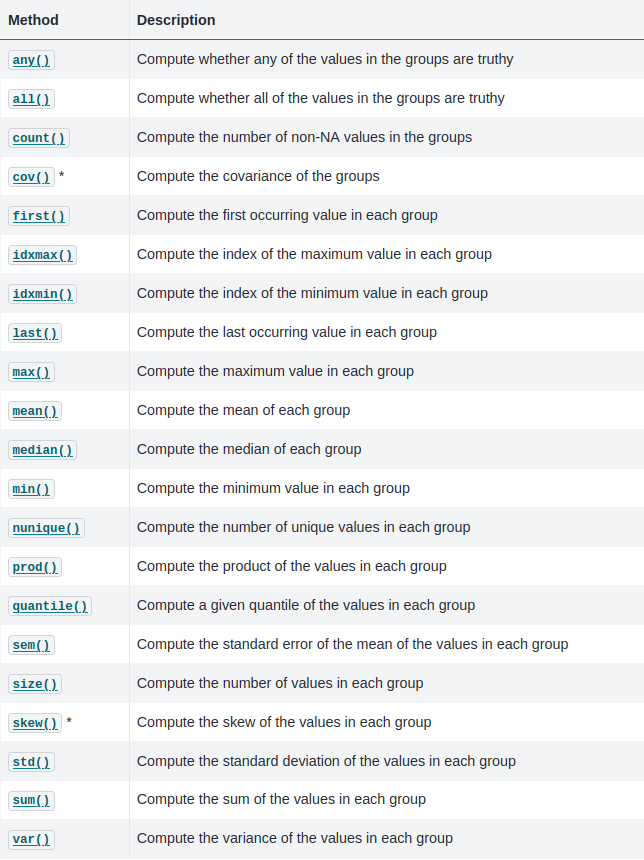

In [ ]:
# ЗАДАНИЕ: 
#         1. Рассчитайте средний тариф (fare) для каждого класса каюты (class). 
#            Отсортируйте результат по убыванию среднего тарифа.
#
#         2. Для каждой комбинации (пол, класс каюты) рассчитайте:
#            - количество пассажиров
#            - средний возраст
#            - процент выживших (количество выживших / общее количество * 100)

avg_fare_by_class = df.groupby(...)['fare']....().sort_values(ascending=False)

sex_class_stats = ...
# Переименуйте столбцы согласно их смыслу
sex_class_stats.columns = ['...', '...', '...']

In [ ]:
# print выводит некрасиво, приятнее использовать приемущества ipynb
avg_fare_by_class

In [ ]:
sex_class_stats

### Подведение итогов (2 pt)

_Теперь вы умеете_
* делать базовый анализ датасета,  
* смотреть распределения данных,  
* фильтровать данные,
* создавать новые фичи,
* агрегировать и считать статистики.

_Пора все знания зафиналить и собрать все вместе._

***

**ЗАДАНИЕ:**  
Для каждой возрастной категории (столбец `age_category`, созданного в одном из заданий) определите:
1. Количество пассажиров
2. Средний тариф
3. Процент выживших
4. Самый популярный порт посадки (режим — наиболее частое значение)

Отсортируйте результат по убыванию процента выживших.

Сделайте **вывод** из тех данных, которое у вас получились

In [ ]:
...

In [ ]:
# Поменяйте тип ячейки на Marcdown, удалите комментарий и напишите вывод
**ВЫВОД:**

**НЕ ЗАБУДЬТЕ ПЕРЕЗАПУСТИТЬ НОУТБУК ТАК, ЧТОБЫ ВСЕ ЯЧЕЙКИ БЫЛИ ЗАПУЩЕНЫ ПОДРЯД, НАЧИНАЯ С [1]**